4*2 이미지를 만드는 코드

Loaded box_1000_False_Oct01_15-32.csv
max p-value: 0.0396037453837146 at epoch 39/200
Loaded box_1000_False_Oct01_22-45.csv
max p-value: 0.0668900105874254 at epoch 78/200
Loaded box_1000_False_Oct03_00-57.csv
max p-value: 0.003607118888322 at epoch 156/200
Loaded box_1000_False_Oct03_18-42.csv
max p-value: 0.0568078457893511 at epoch 199/200
Loaded box_1000_True_Sep23_20-34.csv
max p-value: 0.3167078856694835 at epoch 42/1000
Loaded box_1000_True_Sep24_20-41.csv
max p-value: 0.5100404015542276 at epoch 57/1000
Loaded box_1000_True_Sep25_15-57.csv
max p-value: 0.5053636826000325 at epoch 188/1000
Loaded box_1000_True_Sep26_15-44.csv
max p-value: 0.3020056477259735 at epoch 121/200


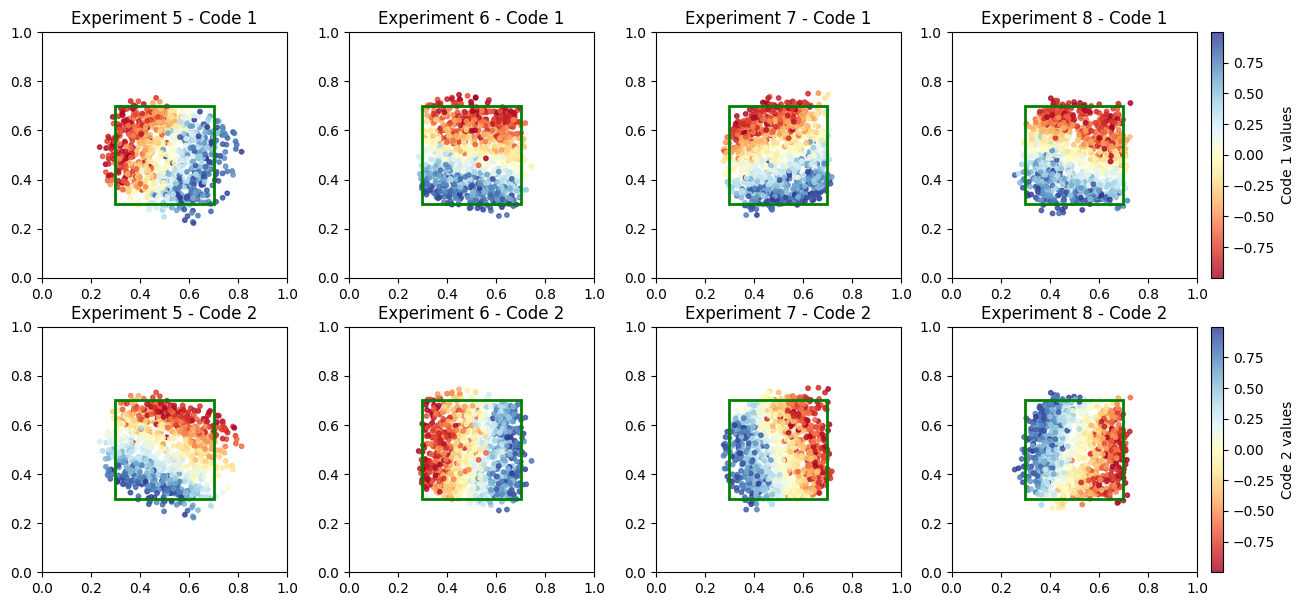

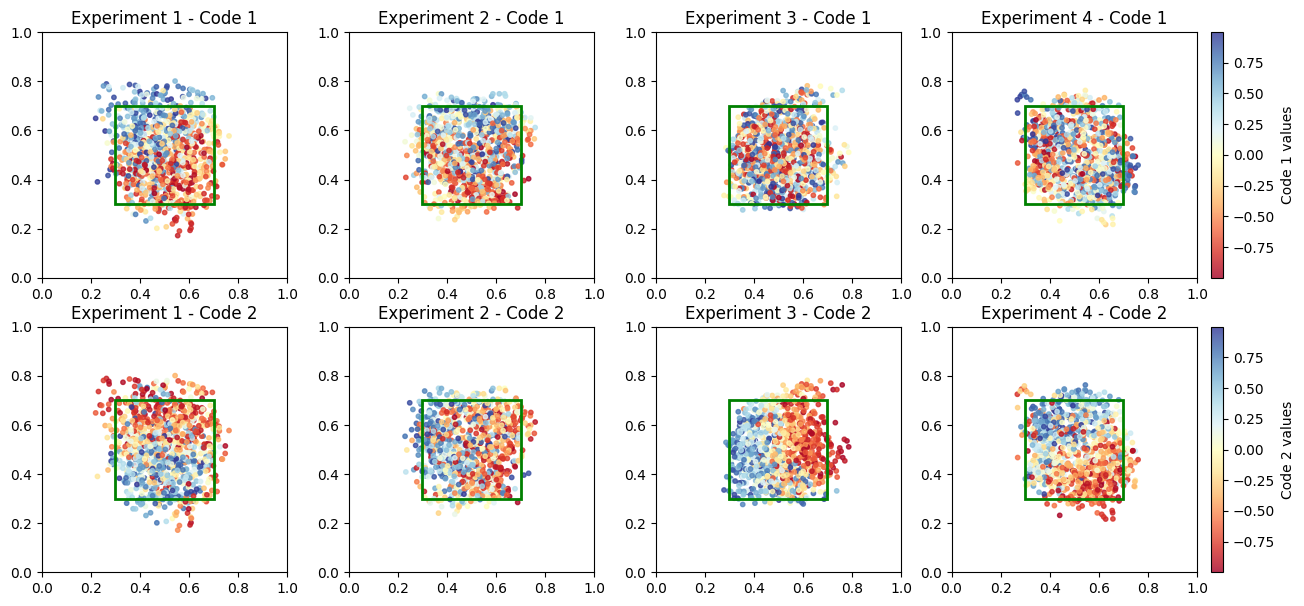

: 

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

result_dir = "../../결과/2D_square"
experiment_names = ["box_1000_False_Oct01_15-32", "box_1000_False_Oct01_22-45",
                    "box_1000_False_Oct03_00-57", "box_1000_False_Oct03_18-42",
                    "box_1000_True_Sep23_20-34", "box_1000_True_Sep24_20-41",
                    "box_1000_True_Sep25_15-57", "box_1000_True_Sep26_15-44"]

# True와 False 실험별로 인덱스를 관리합니다.
true_idx = 0
false_idx = 0

# True와 False에 대한 figure와 axes를 생성합니다.
fig_true, axes_true = plt.subplots(2, 4, figsize=(15, 6), gridspec_kw={'wspace': 0.1})
fig_false, axes_false = plt.subplots(2, 4, figsize=(15, 6), gridspec_kw={'wspace': 0.1})

for idx, experiment_name in enumerate(experiment_names):
    experiment_path = os.path.join(result_dir, f"{experiment_name}.csv")

    df = None
    if os.path.exists(experiment_path):
        # If the file exists, read it into a pandas DataFrame
        df = pd.read_csv(experiment_path)
        print(f"Loaded {experiment_name}.csv")
    else:
        # If the specific file doesn't exist, try to load 'scalars.csv'
        scalars_path = os.path.join(result_dir, "scalars.csv")
        if os.path.exists(scalars_path):
            df = pd.read_csv(scalars_path)
            print(f"{experiment_name}.csv not found. Loaded scalars.csv instead.")
        else:
            print(f"Neither {experiment_name}.csv nor scalars.csv found.")
            continue  # 파일이 없으면 다음 실험으로 넘어갑니다.

    max_p_value = df["p_value"].max()
    epoch_max_p_value = df[df["p_value"] == max_p_value]["epoch"].iloc[0]
    print(f"max p-value: {max_p_value} at epoch {epoch_max_p_value}/{len(df)}")

    # 데이터 파일 경로 설정
    outputs_path = os.path.join(result_dir, experiment_name, f"numpy/gen_outputs_epoch_{epoch_max_p_value}.txt")
    codes_path = os.path.join(result_dir, experiment_name, f"numpy/gen_codes_epoch_{epoch_max_p_value}.txt")

    # 데이터가 존재하는지 확인
    if not os.path.exists(outputs_path) or not os.path.exists(codes_path):
        print(f"Data files for epoch {epoch_max_p_value} not found in {outputs_path}.")
        continue  # 데이터가 없으면 다음 실험으로 넘어갑니다.

    # 데이터 로드
    outputs = np.loadtxt(outputs_path)
    codes = np.loadtxt(codes_path)

    # 첫 번째 코드와 두 번째 코드를 각각 사용하여 색상을 지정합니다.
    code1 = codes[:, 0]
    code2 = codes[:, 1]

    # 플롯할 축 선택
    if "True" in experiment_name:
        ax1 = axes_true[true_idx // 4, true_idx % 4]
        ax2 = axes_true[(true_idx + 4) // 4, (true_idx + 4) % 4]
        true_idx += 1
    else:
        ax1 = axes_false[false_idx // 4, false_idx % 4]
        ax2 = axes_false[(false_idx + 4) // 4, (false_idx + 4) % 4]
        false_idx += 1

    # 첫 번째 코드로 색상 지정하여 플롯 (RdYlBu cmap 및 alpha 값 적용)
    scatter1 = ax1.scatter(outputs[:, 0], outputs[:, 1], c=code1, cmap='RdYlBu', s=10, alpha=0.8)
    ax1.set_title(f'Experiment {idx+1} - Code 1')
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.set_aspect('equal')

    # 초록색 사각형 추가 (위치: [0.3, 0.7]x[0.3, 0.7])
    rect1 = patches.Rectangle((0.3, 0.3), 0.4, 0.4, linewidth=2, edgecolor='green', facecolor='none')
    ax1.add_patch(rect1)

    # 두 번째 코드로 색상 지정하여 플롯 (RdYlBu cmap 및 alpha 값 적용)
    scatter2 = ax2.scatter(outputs[:, 0], outputs[:, 1], c=code2, cmap='RdYlBu', s=10, alpha=0.8)
    ax2.set_title(f'Experiment {idx+1} - Code 2')
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.set_aspect('equal')
    
    # 초록색 사각형 추가 (위치: [0.3, 0.7]x[0.3, 0.7])
    rect2 = patches.Rectangle((0.3, 0.3), 0.4, 0.4, linewidth=2, edgecolor='green', facecolor='none')
    ax2.add_patch(rect2)

# True 실험에 대해 오른쪽 열에만 컬러바 추가
fig_true.subplots_adjust(left=0.05, right=0.85, top=0.95, bottom=0.05)
cbar_true1 = fig_true.colorbar(scatter1, ax=axes_true[0][-1], location='right', fraction=0.05)
cbar_true1.set_label('Code 1 values')
cbar_true2 = fig_true.colorbar(scatter2, ax=axes_true[1][-1], location='right', fraction=0.05)
cbar_true2.set_label('Code 2 values')

# False 실험에 대해 오른쪽 열에만 컬러바 추가
fig_false.subplots_adjust(left=0.05, right=0.85, top=0.95, bottom=0.05)
cbar_false1 = fig_false.colorbar(scatter1, ax=axes_false[0][-1], location='right', fraction=0.05)
cbar_false1.set_label('Code 1 values')
cbar_false2 = fig_false.colorbar(scatter2, ax=axes_false[1][-1], location='right', fraction=0.05)
cbar_false2.set_label('Code 2 values')

# 레이아웃 조정 및 이미지 저장
fig_true.savefig(os.path.join(result_dir, "True_experiments_with_colorbars_horizontal.png"))
fig_false.savefig(os.path.join(result_dir, "False_experiments_with_colorbars_horizontal.png"))

# 현재 경로에도 사진 저장. (최종 이미지는 visualize 루트로 올려 주세요)
fig_true.savefig("tmp/2D_disentanglement_InfoQGAN_horizontal.png")
fig_false.savefig("tmp/2D_disentanglement_QGAN_horizontal.png")

plt.show()


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

result_dir = "/past_runs"
experiment_names = ["box_1000_False_Oct01_15-32", "box_1000_False_Oct01_22-45",
                    "box_1000_False_Oct03_00-57", "box_1000_False_Oct03_18-42",
                    "box_1000_True_Sep23_20-34", "box_1000_True_Sep24_20-41",
                    "box_1000_True_Sep25_15-57", "box_1000_True_Sep26_15-44"]

# True와 False 실험별로 인덱스를 관리합니다.
true_idx = 0
false_idx = 0

# True와 False에 대한 figure와 axes를 생성합니다.
fig_true, axes_true = plt.subplots(2, 4, figsize=(15, 6), gridspec_kw={'wspace': 0.1})
fig_false, axes_false = plt.subplots(2, 4, figsize=(15, 6), gridspec_kw={'wspace': 0.1})

for idx, experiment_name in enumerate(experiment_names):
    experiment_path = os.path.join(result_dir, f"{experiment_name}.csv")

    df = None
    if os.path.exists(experiment_path):
        # If the file exists, read it into a pandas DataFrame
        df = pd.read_csv(experiment_path)
        print(f"Loaded {experiment_name}.csv")
    else:
        # If the specific file doesn't exist, try to load 'scalars.csv'
        scalars_path = os.path.join(result_dir, "scalars.csv")
        if os.path.exists(scalars_path):
            df = pd.read_csv(scalars_path)
            print(f"{experiment_name}.csv not found. Loaded scalars.csv instead.")
        else:
            print(f"Neither {experiment_name}.csv nor scalars.csv found.")
            continue  # 파일이 없으면 다음 실험으로 넘어갑니다.

    max_p_value = df["p_value"].max()
    epoch_max_p_value = df[df["p_value"] == max_p_value]["epoch"].iloc[0]
    print(f"max p-value: {max_p_value} at epoch {epoch_max_p_value}/{len(df)}")

    # 데이터 파일 경로 설정
    outputs_path = os.path.join(result_dir, experiment_name, f"numpy/gen_outputs_epoch_{epoch_max_p_value}.txt")
    codes_path = os.path.join(result_dir, experiment_name, f"numpy/gen_codes_epoch_{epoch_max_p_value}.txt")

    # 데이터가 존재하는지 확인
    if not os.path.exists(outputs_path) or not os.path.exists(codes_path):
        print(f"Data files for epoch {epoch_max_p_value} not found in {outputs_path}.")
        continue  # 데이터가 없으면 다음 실험으로 넘어갑니다.

    # 데이터 로드
    outputs = np.loadtxt(outputs_path)
    codes = np.loadtxt(codes_path)

    # 첫 번째 코드와 두 번째 코드를 각각 사용하여 색상을 지정합니다.
    code1 = codes[:, 0]
    code2 = codes[:, 1]

    # 플롯할 축 선택
    if "True" in experiment_name:
        ax1 = axes_true[true_idx // 4, true_idx % 4]
        ax2 = axes_true[(true_idx + 4) // 4, (true_idx + 4) % 4]
        true_idx += 1
    else:
        ax1 = axes_false[false_idx // 4, false_idx % 4]
        ax2 = axes_false[(false_idx + 4) // 4, (false_idx + 4) % 4]
        false_idx += 1

    # 첫 번째 코드로 색상 지정하여 플롯 (RdYlBu cmap 및 alpha 값 적용)
    scatter1 = ax1.scatter(outputs[:, 0], outputs[:, 1], c=code1, cmap='RdYlBu', s=10, alpha=0.8)
    ax1.set_title(f'Experiment {idx+1} - Code 1')
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.set_aspect('equal')

    # 초록색 사각형 추가 (위치: [0.3, 0.7]x[0.3, 0.7])
    rect1 = patches.Rectangle((0.3, 0.3), 0.4, 0.4, linewidth=2, edgecolor='green', facecolor='none')
    ax1.add_patch(rect1)

    # 두 번째 코드로 색상 지정하여 플롯 (RdYlBu cmap 및 alpha 값 적용)
    scatter2 = ax2.scatter(outputs[:, 0], outputs[:, 1], c=code2, cmap='RdYlBu', s=10, alpha=0.8)
    ax2.set_title(f'Experiment {idx+1} - Code 2')
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.set_aspect('equal')
    
    # 초록색 사각형 추가 (위치: [0.3, 0.7]x[0.3, 0.7])
    rect2 = patches.Rectangle((0.3, 0.3), 0.4, 0.4, linewidth=2, edgecolor='green', facecolor='none')
    ax2.add_patch(rect2)

# True 실험에 대해 오른쪽 열에만 컬러바 추가
fig_true.subplots_adjust(left=0.05, right=0.85, top=0.95, bottom=0.05)
cbar_true1 = fig_true.colorbar(scatter1, ax=axes_true[0][-1], location='right', fraction=0.05)
cbar_true1.set_label('Code 1 values')
cbar_true2 = fig_true.colorbar(scatter2, ax=axes_true[1][-1], location='right', fraction=0.05)
cbar_true2.set_label('Code 2 values')

# False 실험에 대해 오른쪽 열에만 컬러바 추가
fig_false.subplots_adjust(left=0.05, right=0.85, top=0.95, bottom=0.05)
cbar_false1 = fig_false.colorbar(scatter1, ax=axes_false[0][-1], location='right', fraction=0.05)
cbar_false1.set_label('Code 1 values')
cbar_false2 = fig_false.colorbar(scatter2, ax=axes_false[1][-1], location='right', fraction=0.05)
cbar_false2.set_label('Code 2 values')

# 레이아웃 조정 및 이미지 저장
fig_true.savefig(os.path.join(result_dir, "True_experiments_with_colorbars_horizontal.png"))
fig_false.savefig(os.path.join(result_dir, "False_experiments_with_colorbars_horizontal.png"))

# 현재 경로에도 사진 저장. (최종 이미지는 visualize 루트로 올려 주세요)
fig_true.savefig("tmp/2D_disentanglement_InfoQGAN_horizontal.png")
fig_false.savefig("tmp/2D_disentanglement_QGAN_horizontal.png")

plt.show()
